In [20]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [22]:
df = pd.read_csv("customer_data.csv", encoding="ISO-8859-1")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850.0,United Kingdom


In [23]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (541909, 8)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [24]:
# Create a copy before cleaning
df_clean = df.copy()

# Remove rows with missing CustomerID
df_clean = df_clean.dropna(subset=["CustomerID"])

# Convert CustomerID to integer
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int)

# Convert InvoiceDate to datetime format
df_clean["InvoiceDate"] = pd.to_datetime(
    df_clean["InvoiceDate"],
    format="mixed"
)

# Remove cancelled transactions
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C")]

# Remove invalid quantities and prices
df_clean = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["UnitPrice"] > 0)
]

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

print("Original Dataset Shape:", df.shape)
print("Cleaned Dataset Shape:", df_clean.shape)

print("\nMissing Values After Cleaning:")
print(df_clean.isnull().sum())

Original Dataset Shape: (541909, 8)
Cleaned Dataset Shape: (392692, 8)

Missing Values After Cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [25]:
# Calculate total purchase value for each transaction
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]

# Display cleaned data
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [26]:
# Descriptive Statistics

# Average Purchase Value
average_purchase_value = df_clean["TotalPrice"].mean()

# Average Purchase Frequency per Customer
purchase_frequency = (
    df_clean.groupby("CustomerID")["InvoiceNo"].nunique().mean()
)

# Average Customer Lifetime Value
customer_value = (
    df_clean.groupby("CustomerID")["TotalPrice"].sum()
)

average_customer_lifetime_value = customer_value.mean()

print("Average Purchase Value:", round(average_purchase_value, 2))
print("Average Purchase Frequency per Customer:", round(purchase_frequency, 2))
print("Average Customer Lifetime Value:", round(average_customer_lifetime_value, 2))

Average Purchase Value: 22.63
Average Purchase Frequency per Customer: 4.27
Average Customer Lifetime Value: 2048.69


In [27]:
# Set reference date as one day after the latest transaction
reference_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

# Create RFM table
rfm = df_clean.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
}).reset_index()

# Rename columns
rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

# Display first 10 customers
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
5,12352,36,8,2506.04
6,12353,204,1,89.00
7,12354,232,1,1079.40
8,12355,214,1,459.40
9,12356,23,3,2811.43


In [28]:
# Statistical summary of RFM features
rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [29]:
# Remove extreme outliers using the IQR method

rfm_clean = rfm.copy()

for column in ["Recency", "Frequency", "Monetary"]:
    Q1 = rfm_clean[column].quantile(0.25)
    Q3 = rfm_clean[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    rfm_clean = rfm_clean[
        (rfm_clean[column] >= lower_bound) &
        (rfm_clean[column] <= upper_bound)
    ]

print("Customers before outlier removal:", len(rfm))
print("Customers after outlier removal:", len(rfm_clean))

rfm_clean[["Recency", "Frequency", "Monetary"]].describe()

Customers before outlier removal: 4338
Customers after outlier removal: 3604


,Recency,Frequency,Monetary
count,3604.000000,3604.000000,3604.000000
mean,91.591565,2.725305,810.507925
std,89.476857,2.078667,700.459846
min,1.000000,1.000000,3.750000
25%,22.000000,1.000000,286.565000
50%,57.000000,2.000000,576.980000
75%,144.250000,4.000000,1138.432500
max,327.000000,11.000000,3029.870000


In [30]:
# Select RFM features for clustering
rfm_features = rfm_clean[["Recency", "Frequency", "Monetary"]]

# Standardize the features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# Convert scaled data into a DataFrame
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"]
)

rfm_scaled_df.head()

,Recency,Frequency,Monetary
0,-0.185454,0.613312,1.408887
1,-0.811401,-0.830121,1.352217
2,2.441288,-0.830121,-0.679802
3,-0.621382,2.537889,2.420934
4,1.256459,-0.830121,-1.030192


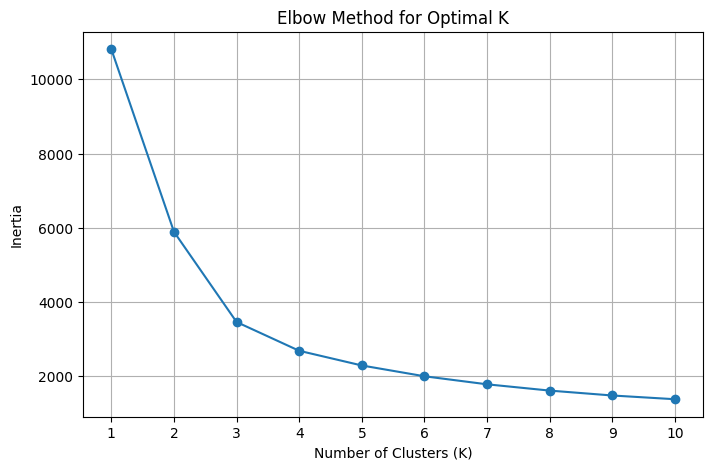

In [31]:
# Elbow Method to find the optimal number of clusters

inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(K_range)
plt.grid(True)

plt.show()

In [32]:
# Apply K-Means clustering with optimal K = 3

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Assign cluster labels
rfm_clean["Cluster"] = kmeans.fit_predict(rfm_scaled)

# Display the results
rfm_clean.head(10)

,CustomerID,Recency,Frequency,Monetary,Cluster
2,12348,75,4,1797.24,1
3,12349,19,1,1757.55,0
4,12350,310,1,334.40,2
5,12352,36,8,2506.04,1
6,12353,204,1,89.00,2
7,12354,232,1,1079.40,2
8,12355,214,1,459.40,2
9,12356,23,3,2811.43,1
11,12358,2,2,1168.06,0
13,12360,52,3,2662.06,1


In [33]:
# Calculate average RFM values for each cluster

cluster_profile = rfm_clean.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean",
    "CustomerID": "count"
}).round(2)

# Rename CustomerID column
cluster_profile.rename(
    columns={"CustomerID": "Number_of_Customers"},
    inplace=True
)

cluster_profile

,Recency,Frequency,Monetary,Number_of_Customers
Cluster,,,,
0,49.56,2.03,556.25,1879
1,37.18,5.69,1844.40,819
2,227.94,1.49,403.20,906


In [34]:
# Assign meaningful names to each cluster

cluster_names = {
    0: "Regular Customers",
    1: "High-Value Customers",
    2: "At-Risk Customers"
}

rfm_clean["Segment"] = rfm_clean["Cluster"].map(cluster_names)

rfm_clean.head(10)

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
2,12348,75,4,1797.24,1,High-Value Customers
3,12349,19,1,1757.55,0,Regular Customers
4,12350,310,1,334.40,2,At-Risk Customers
5,12352,36,8,2506.04,1,High-Value Customers
6,12353,204,1,89.00,2,At-Risk Customers
7,12354,232,1,1079.40,2,At-Risk Customers
8,12355,214,1,459.40,2,At-Risk Customers
9,12356,23,3,2811.43,1,High-Value Customers
11,12358,2,2,1168.06,0,Regular Customers
13,12360,52,3,2662.06,1,High-Value Customers


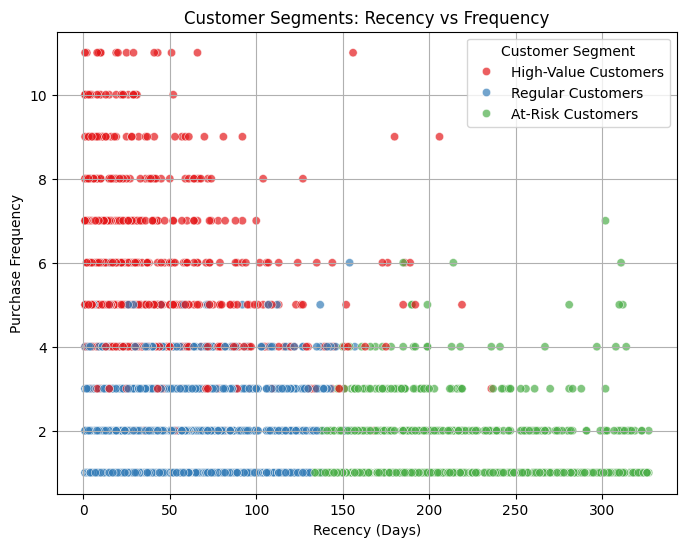

In [35]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm_clean,
    x="Recency",
    y="Frequency",
    hue="Segment",
    palette="Set1",
    alpha=0.7
)

plt.title("Customer Segments: Recency vs Frequency")
plt.xlabel("Recency (Days)")
plt.ylabel("Purchase Frequency")
plt.legend(title="Customer Segment")
plt.grid(True)

plt.show()

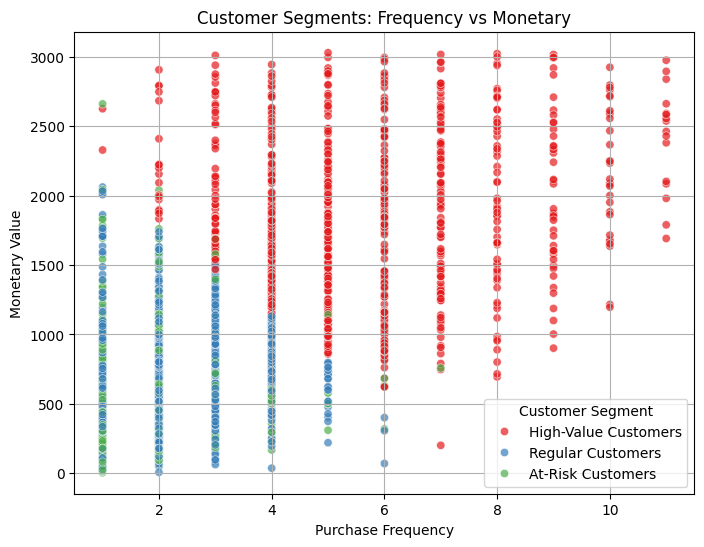

In [36]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm_clean,
    x="Frequency",
    y="Monetary",
    hue="Segment",
    palette="Set1",
    alpha=0.7
)

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.legend(title="Customer Segment")
plt.grid(True)

plt.show()

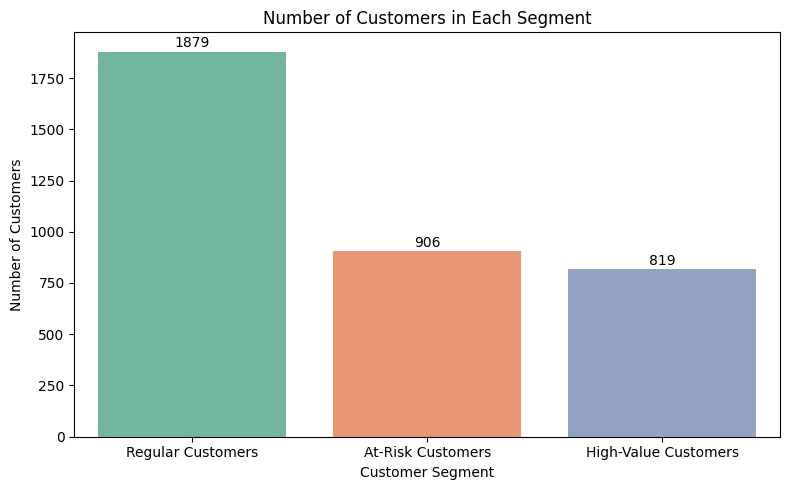

In [37]:
# Count customers in each segment
segment_counts = rfm_clean["Segment"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values,
    hue=segment_counts.index,
    palette="Set2",
    legend=False
)

plt.title("Number of Customers in Each Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

# Display count above each bar
for i, value in enumerate(segment_counts.values):
    plt.text(i, value + 20, str(value), ha="center")

plt.tight_layout()
plt.show()

## Customer Segment Insights & Marketing Recommendations

### 1. High-Value Customers
- These customers purchase frequently and have the highest average spending.
- They are the most valuable and loyal customer group.
- **Recommendation:** Provide loyalty rewards, exclusive discounts, early access to new products, and personalized recommendations.

### 2. Regular Customers
- These customers purchase moderately and have an average spending level.
- They form the largest customer segment.
- **Recommendation:** Encourage repeat purchases through targeted promotions, product recommendations, and loyalty programs.

### 3. At-Risk Customers
- These customers have not purchased for a long time and show low purchase frequency and spending.
- They may be becoming inactive customers.
- **Recommendation:** Use re-engagement campaigns, comeback discounts, reminder emails, and limited-time offers to encourage them to purchase again.

## Conclusion

The Customer Segmentation Analysis successfully grouped customers into three distinct segments using RFM analysis and K-Means clustering: High-Value Customers, Regular Customers, and At-Risk Customers.

The Elbow Method was used to determine an optimal value of K = 3, and the RFM features were standardized using StandardScaler before clustering. The resulting customer segments provide useful insights into purchasing behaviour and can help the company develop targeted marketing strategies, improve customer retention, and strengthen relationships with valuable customers.

# Customer Segmentation Analysis Using K-Means Clustering

## Objective
The objective of this project is to segment an e-commerce company's customers into distinct groups based on their purchasing behaviour. RFM (Recency, Frequency, Monetary) analysis and K-Means clustering are used to identify customer segments and provide targeted marketing recommendations.

## Dataset
The Online Retail e-commerce dataset is used for this analysis. It contains transactional information such as invoice number, product details, quantity, invoice date, unit price, customer ID, and country.

## Technologies Used
- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn
- Jupyter Notebook